In [1]:
!pip3 install numpy matplotlib control

In [17]:
import control as ct
import matplotlib.pyplot as plt
import numpy as np

In [30]:
# 1. Define the Transfer Function G(s) = 3 / (8s^4 + 8s^3 + 24s^2 + 12s)
num = [3]
den = [8, 8, 24, 12, 0] # Denominator has root at s=0 (Type 1)
sys = ct.TransferFunction(num, den)

print("Transfer Function G(s):")
print(sys)


Transfer Function G(s):
<TransferFunction>: sys[36]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

                3
  -----------------------------
  8 s^4 + 8 s^3 + 24 s^2 + 12 s


In [31]:
# 2. Performance Metrics & Transient Analysis
t, y = ct.step_response(sys)
# Note: Settling metrics might not apply for Type 1 systems
info = ct.step_info(sys)
print(f"Step Info: {info}")

Step Info: {'RiseTime': nan, 'SettlingTime': nan, 'SettlingMin': nan, 'SettlingMax': nan, 'Overshoot': nan, 'Undershoot': nan, 'Peak': inf, 'PeakTime': inf, 'SteadyStateValue': nan}


In [32]:
# 3. Frequency Response Analysis (Stability Margins)
gm, pm, wg, wp = ct.margin(sys)
print(f"Gain Margin: {gm}")
print(f"Phase Margin: {pm} deg")
print(f"Crossover Frequencies: Gain={wg}, Phase={wp}")


Gain Margin: 6.0
Phase Margin: 64.48696358320251 deg
Crossover Frequencies: Gain=1.224744871391589, Phase=0.23418392017311865


In [33]:
# 4. Visualization
plt.figure(figsize=(12, 10))


<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

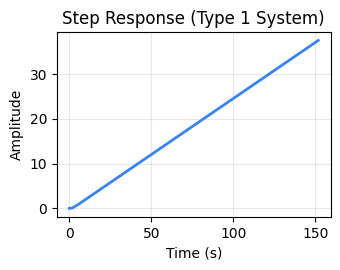

In [34]:
# Plot 1: Step Response
plt.subplot(221)
plt.plot(t, y, color='#3b82f6', linewidth=2)
plt.title('Step Response (Type 1 System)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


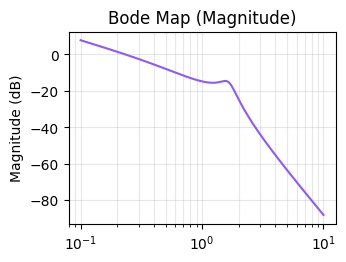

In [38]:
# Plot 3: Bode Magnitude
plt.subplot(223)
mag, phase, omega = ct.bode(sys, plot=False)
plt.semilogx(omega, 20*np.log10(mag), color='#8b5cf6')
plt.title('Bode Map (Magnitude)')
plt.ylabel('Magnitude (dB)')
plt.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

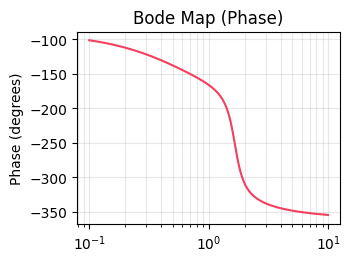

In [37]:
# Plot 4: Bode Phase
plt.subplot(224)
plt.semilogx(omega, np.degrees(phase), color='#f43f5e')
plt.title('Bode Map (Phase)')
plt.ylabel('Phase (degrees)')
plt.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()